Creating of datasets (dimensionless, no_multicoll) with polinomial features

# Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PolynomialFeatures as pf

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_pf(df):
    df_We_Re = df[['We', 'Re']].copy()
    df_We_Re['We^(1/4)'] = df_We_Re['We']**(1/4)
    df_We_Re['Re^(1/4)'] = df_We_Re['Re']**(1/4)

    poly = pf(3, include_bias=False)
    poly_data = poly.fit_transform(df_We_Re[['We^(1/4)', 'Re^(1/4)']])
    df_pf = pd.DataFrame(
        data=poly_data, 
        columns=poly.get_feature_names_out(),
    )
    return df_pf


def create_pf_dataset(
    df,
    orig_features_drop = ['We', 'Re', 'We_Re'],
    pf_columns_drop = [
        'Re^(1/4)^2', 'Re^(1/4)^3', 
        'We^(1/4)', 'We^(1/4)^3',
        'We^(1/4) Re^(1/4)',
        'We^(1/4) Re^(1/4)^2',
    ],
):
    df_pf = get_pf(df)
    # Drop orig features multicorrelated with pf
    df = df.drop(orig_features_drop, axis=1)
    # Drop multicorrelated pf
    df_pf = df_pf.drop(pf_columns_drop, axis=1)
    
    df = pd.concat(
        (df, df_pf),
        axis=1
    )
    
    return df
    
    
def get_correlation_count(row):
    cnt = 0
    for value in row:
        if abs(value) >= 0.9:
            cnt += 1
    return cnt - 1 # exclude autocorrelation


def plot_heatmap(df, name, figsize=None):
    corr = df.corr()
    
    fig, ax = plt.subplots(1,1, figsize=figsize)
    sns.heatmap(corr, annot=True, fmt='.2g', ax=ax)
    plt.title(f'Correlation map PF, {name}')
    plt.show()
    
    display(
        corr.apply(get_correlation_count, axis=1).sort_values(ascending=False)
    )
    
    return corr

In [3]:
path_data = Path('../data/')
xlsxs = ['df_modelling_dimensionless', 'df_modelling_no_multicollinearity']

# Datasets analysis

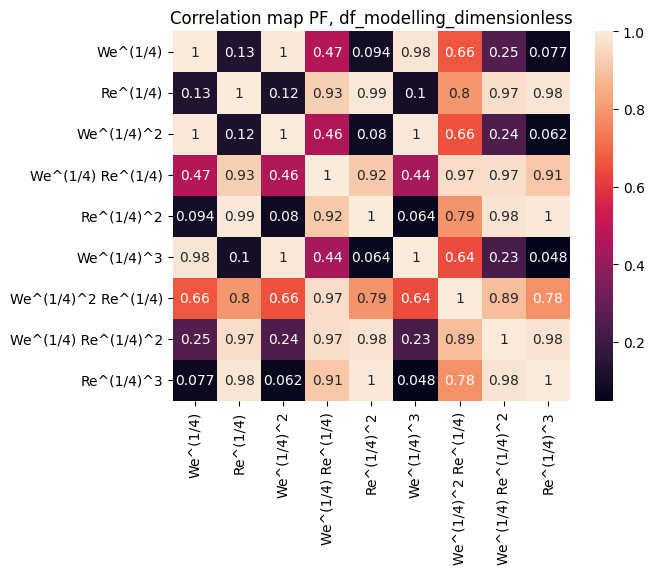

We^(1/4) Re^(1/4)      5
Re^(1/4)               4
Re^(1/4)^2             4
We^(1/4) Re^(1/4)^2    4
Re^(1/4)^3             4
We^(1/4)               2
We^(1/4)^2             2
We^(1/4)^3             2
We^(1/4)^2 Re^(1/4)    1
dtype: int64

In [4]:
filename = xlsxs[0]
df = pd.read_excel(path_data / f'{filename}.xlsx')

df_pf = get_pf(df)

corr = plot_heatmap(df_pf, name=filename)

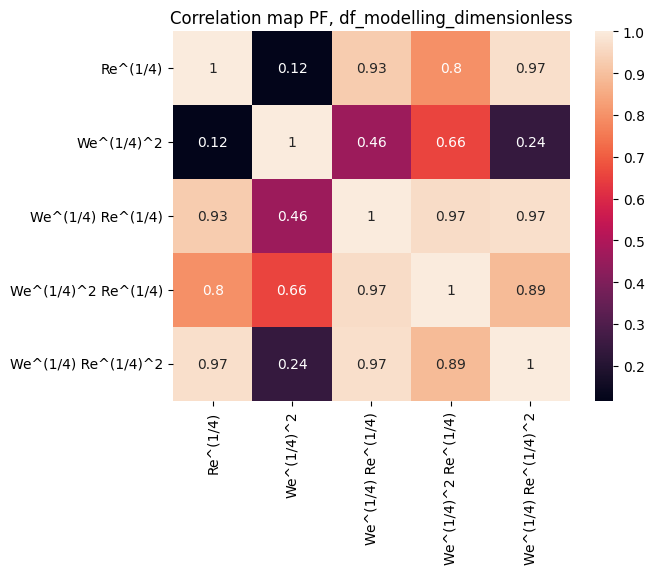

We^(1/4) Re^(1/4)      3
Re^(1/4)               2
We^(1/4) Re^(1/4)^2    2
We^(1/4)^2 Re^(1/4)    1
We^(1/4)^2             0
dtype: int64

In [5]:
# Drop multicorrelated features
df_pf = df_pf.drop(
    ['Re^(1/4)^2', 'Re^(1/4)^3', 'We^(1/4)', 'We^(1/4)^3'], axis=1
)
corr = plot_heatmap(df_pf, name=filename)

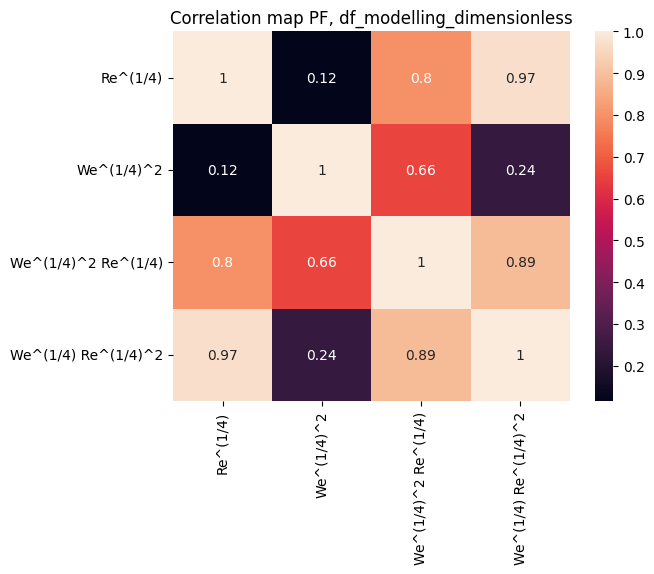

Re^(1/4)               1
We^(1/4) Re^(1/4)^2    1
We^(1/4)^2             0
We^(1/4)^2 Re^(1/4)    0
dtype: int64

In [6]:
df_pf = df_pf.drop(
    ['We^(1/4) Re^(1/4)'], axis=1
)
corr = plot_heatmap(df_pf, name=filename)

Add to whole dimensionless dataset and check multicollinearity then

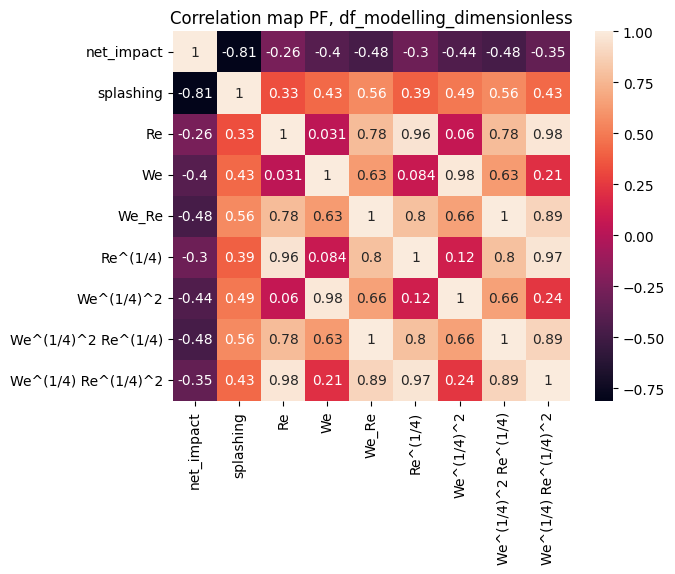

Re                     2
Re^(1/4)               2
We^(1/4) Re^(1/4)^2    2
We                     1
We_Re                  1
We^(1/4)^2             1
We^(1/4)^2 Re^(1/4)    1
net_impact             0
splashing              0
dtype: int64

In [7]:
df = pd.concat(
    (df, df_pf),
    axis=1
)

columns_to_corr = [
    'net_impact', 'splashing', 'Re', 'We',
    'We_Re', 'Re^(1/4)', 'We^(1/4)^2', 'We^(1/4)^2 Re^(1/4)',
    'We^(1/4) Re^(1/4)^2'
]

corr = plot_heatmap(df[columns_to_corr], name=filename)

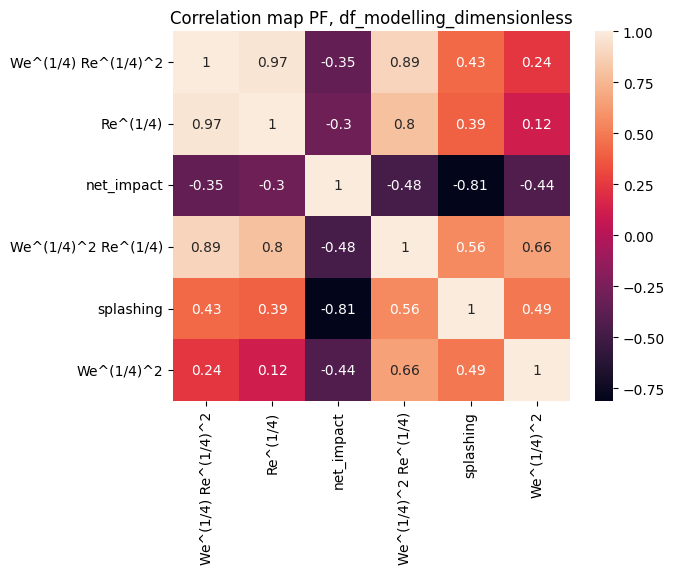

We^(1/4) Re^(1/4)^2    1
Re^(1/4)               1
net_impact             0
We^(1/4)^2 Re^(1/4)    0
splashing              0
We^(1/4)^2             0
dtype: int64

In [8]:
cols_to_drop = ['We_Re', 'Re', 'We']

df = df.drop(
    cols_to_drop, 
    axis=1,
)

columns_to_corr = list(set(columns_to_corr) - set(cols_to_drop))

corr = plot_heatmap(df[columns_to_corr], name=filename)

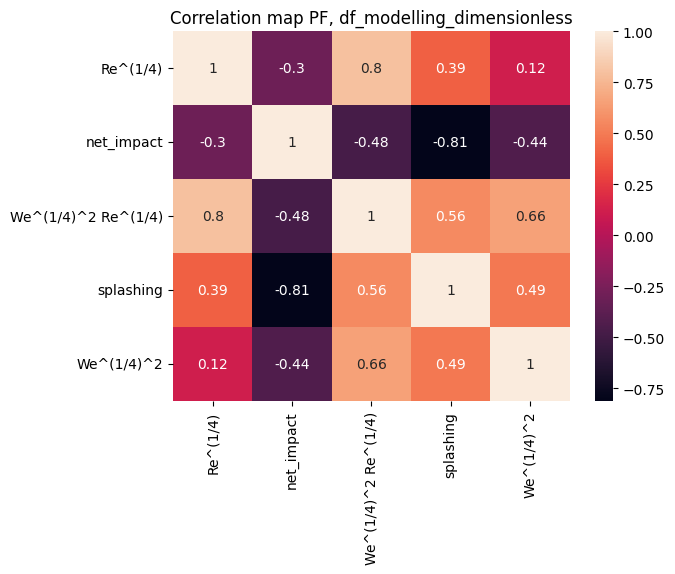

Re^(1/4)               0
net_impact             0
We^(1/4)^2 Re^(1/4)    0
splashing              0
We^(1/4)^2             0
dtype: int64

In [9]:
cols_to_drop = ['We^(1/4) Re^(1/4)^2']

df = df.drop(
    cols_to_drop, 
    axis=1,
)

columns_to_corr = list(set(columns_to_corr) - set(cols_to_drop))

corr = plot_heatmap(df[columns_to_corr], name=filename)

In [10]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   net_impact                       372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   inclination                      372 non-null    int64  
 4   roughness_binary                 372 non-null    int64  
 5   particle_liquid_density_ratio    372 non-null    float64
 6   volume_fraction_binary           372 non-null    int64  
 7   particle_droplet_diameter_ratio  372 non-null    float64
 8   Re^(1/4)                         372 non-null    float64
 9   We^(1/4)^2                       372 non-null    float64
 10  We^(1/4)^2 Re^(1/4)              372 non-null    float64
dtypes: float64(5), int64(6)
memory usage: 32.1 KB


,net_impact,splashing,wettability,inclination,roughness_binary,particle_liquid_density_ratio,volume_fraction_binary,particle_droplet_diameter_ratio,Re^(1/4),We^(1/4)^2,We^(1/4)^2 Re^(1/4)
0,0,1,0,0,0,1.219512,1,0.013301,6.215553,38.630329,240.108847
1,0,1,0,0,0,1.219512,1,0.013301,6.215553,38.630329,240.108847
2,0,1,0,0,0,1.219512,1,0.013301,6.215553,38.630329,240.108847
3,0,1,1,0,0,1.219512,1,0.013833,6.154906,37.880155,233.148786
4,0,1,1,0,0,1.219512,1,0.013833,6.154906,37.880155,233.148786
...,...,...,...,...,...,...,...,...,...,...,...
367,0,0,2,20,0,1.016949,1,0.082335,4.287476,15.089321,64.695100
368,0,1,0,20,0,1.016949,1,0.083333,4.274581,14.998693,64.113132
369,0,1,0,20,0,1.016949,1,0.084098,4.264833,14.930362,63.675499
370,0,0,1,20,0,1.016949,1,0.082090,4.290682,15.111892,64.840319


# PF Datasets creation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   net_impact                       372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   inclination                      372 non-null    int64  
 4   roughness_binary                 372 non-null    int64  
 5   particle_liquid_density_ratio    372 non-null    float64
 6   volume_fraction_binary           372 non-null    int64  
 7   particle_droplet_diameter_ratio  372 non-null    float64
 8   Re^(1/4)                         372 non-null    float64
 9   We^(1/4)^2                       372 non-null    float64
 10  We^(1/4)^2 Re^(1/4)              372 non-null    float64
dtypes: float64(5), int64(6)
memory usage: 32.1 KB


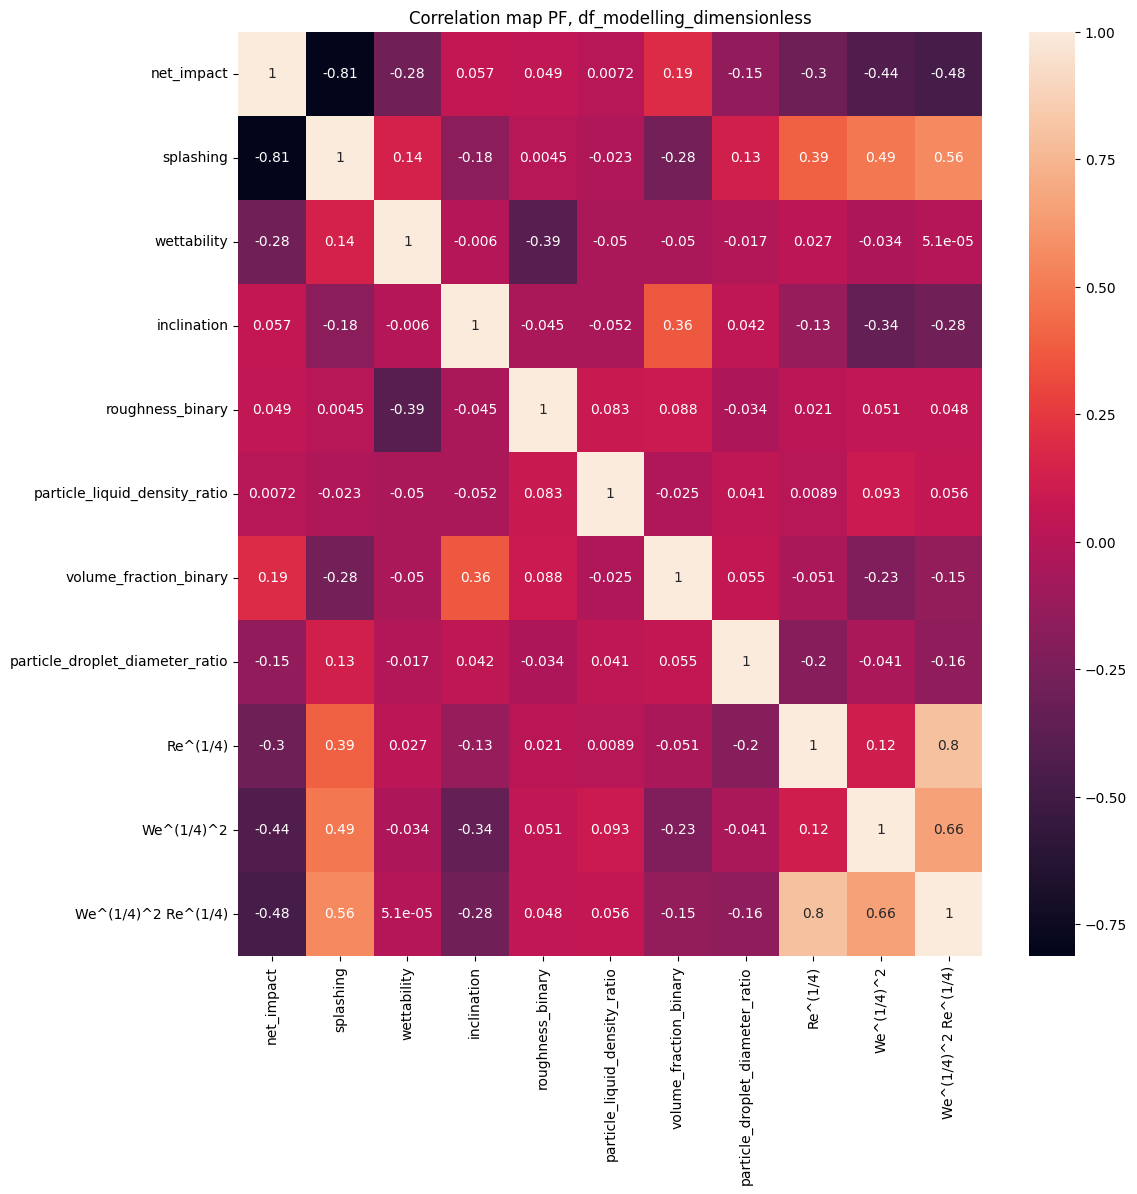

net_impact                         0
splashing                          0
wettability                        0
inclination                        0
roughness_binary                   0
particle_liquid_density_ratio      0
volume_fraction_binary             0
particle_droplet_diameter_ratio    0
Re^(1/4)                           0
We^(1/4)^2                         0
We^(1/4)^2 Re^(1/4)                0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   net_impact                       372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   liquid_density                   372 non-null    int64  
 4   surface_tension                  372 non-null    float64
 5   viscosity                        372 non-null    float64
 6   droplet_diameter                 372 non-null    float64
 7   inclination                      372 non-null    int64  
 8   roughness_binary                 372 non-null    int64  
 9   particle_liquid_density_ratio    372 non-null    float64
 10  volume_fraction_binary           372 non-null    int64  
 11  particle_droplet_diameter_ratio  372 non-null    float64
 12  Re^(1/4)              

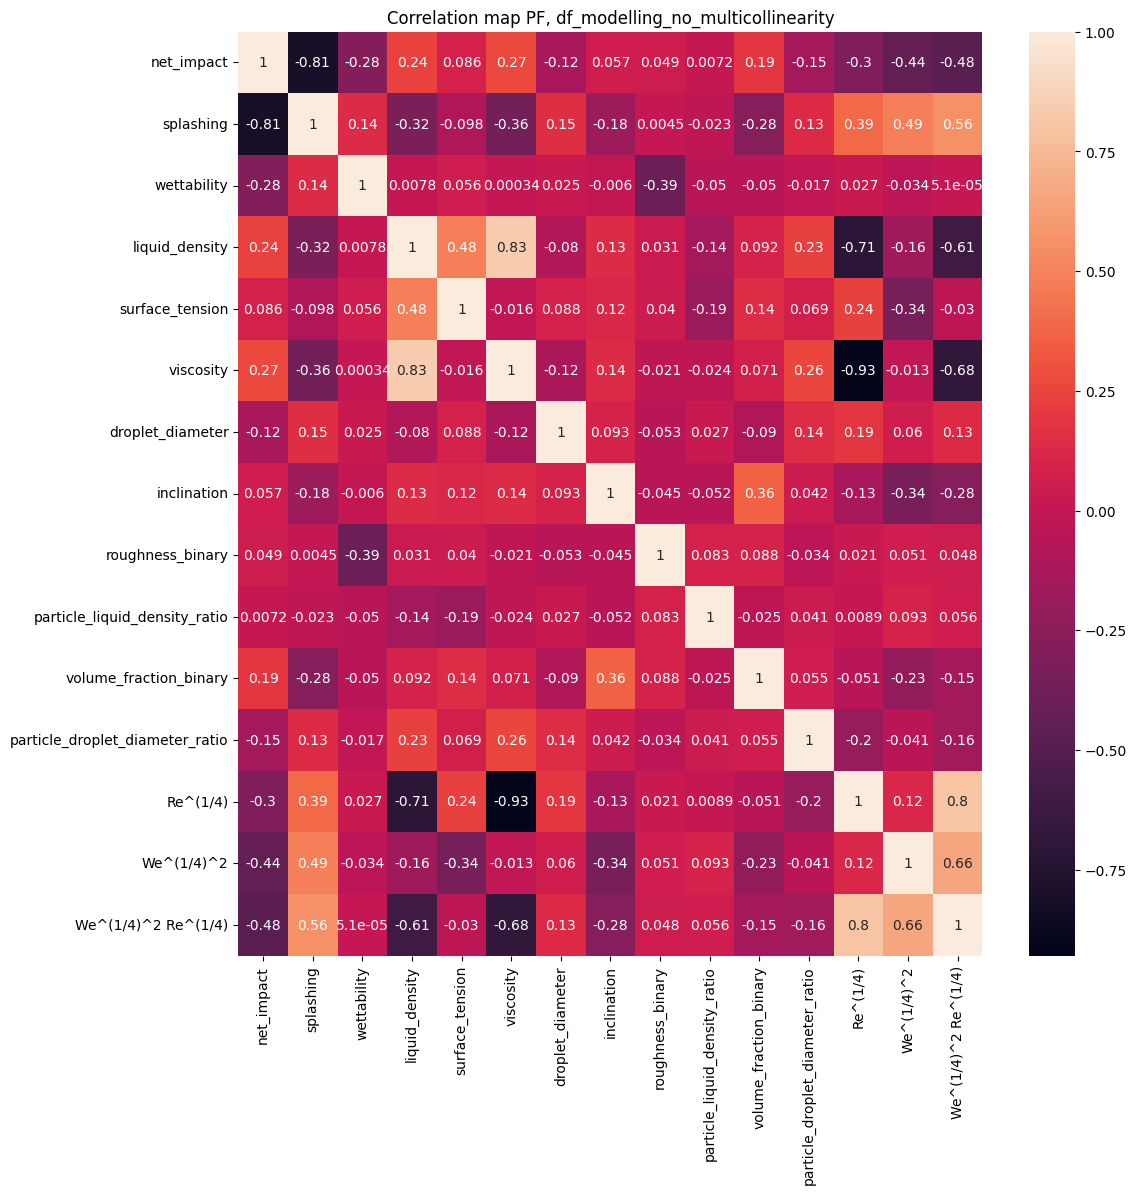

viscosity                          1
Re^(1/4)                           1
net_impact                         0
splashing                          0
wettability                        0
liquid_density                     0
surface_tension                    0
droplet_diameter                   0
inclination                        0
roughness_binary                   0
particle_liquid_density_ratio      0
volume_fraction_binary             0
particle_droplet_diameter_ratio    0
We^(1/4)^2                         0
We^(1/4)^2 Re^(1/4)                0
dtype: int64

In [11]:
df_dt = {}

for filename in xlsxs:
    df = pd.read_excel(path_data / f'{filename}.xlsx')
    df = create_pf_dataset(df)
    df.info()
    df_dt[filename + '_pf'] = df
    
    plot_heatmap(df, name=filename, figsize=(12,12))

Let us drop viscosity as highly correlated features

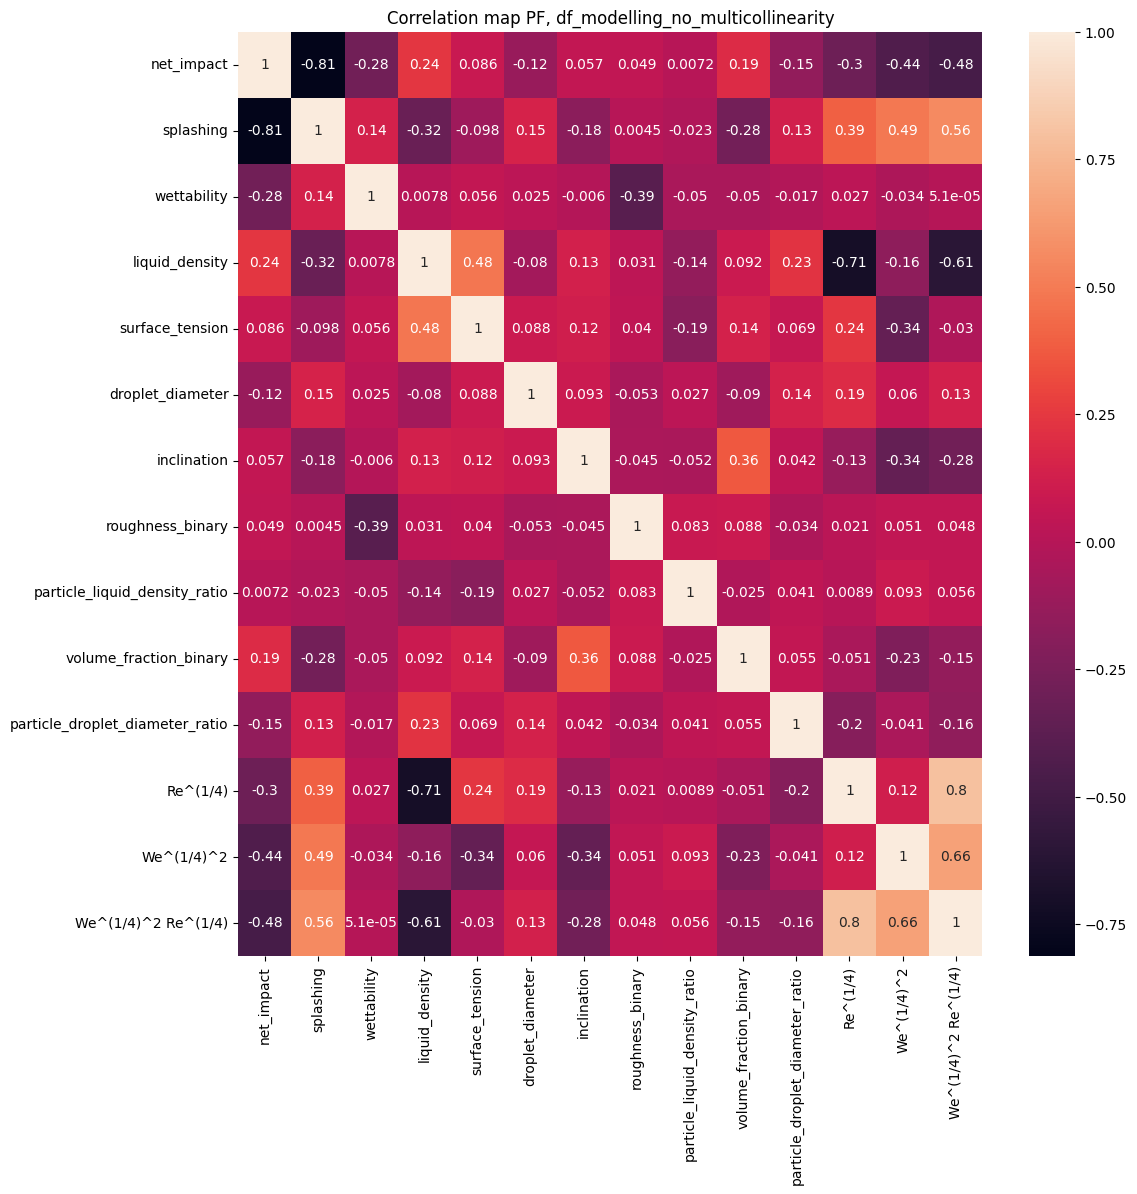

net_impact                         0
splashing                          0
wettability                        0
liquid_density                     0
surface_tension                    0
droplet_diameter                   0
inclination                        0
roughness_binary                   0
particle_liquid_density_ratio      0
volume_fraction_binary             0
particle_droplet_diameter_ratio    0
Re^(1/4)                           0
We^(1/4)^2                         0
We^(1/4)^2 Re^(1/4)                0
dtype: int64

In [12]:
df_dt['df_modelling_no_multicollinearity_pf'] =\
    df_dt['df_modelling_no_multicollinearity_pf'].drop('viscosity', axis=1)
    
plot_heatmap(
    df_dt['df_modelling_no_multicollinearity_pf'], 
    name=xlsxs[1], 
    figsize=(12,12)
);

In [13]:
for filename in df_dt:
    df_dt[filename].to_excel(
    path_data / f'{filename}.xlsx', 
    index=False,
)

In [13]:
df_dt['df_modelling_dimensionless_pf'].shape

(372, 11)

In [14]:
df_dt['df_modelling_no_multicollinearity_pf'].shape

(372, 14)

In [11]:
# for filename in xlsxs:
#     df = pd.read_excel(path_data / f'{filename}.xlsx')

#     poly = pf(3)
#     poly_data = poly.fit_transform(df[['We', 'Re']])
#     poly_features = [f'PF_{x}' for x in poly.get_feature_names_out()]
#     df_pf = pd.DataFrame(data=poly_data, columns=poly_features).iloc[:, 1:]
#     sns.heatmap(df_pf.corr(), annot=True, fmt='.2g')
#     plt.title(f'Correlation map PF, {filename}')
#     plt.show()

#     # Creating correlation matrix
#     cor_matrix = df_pf.corr().abs()
#     # Selecting upper triangle of correlation matrix
#     upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),
#                                         k=1).astype(bool))
#     # Finding index of feature columns with correlation greater than 0.8
#     to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
#     # Droping Marked Features
#     df1 = df_pf.drop(columns=to_drop, axis=1)
#     print(f'Features with correlation <= 0.8\n{df1.columns}')